In [1]:
import os
import gc
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))
from srlib.dataset.loading import load_edsr_dataset
from srlib.dataset.visualization import plot_patch_pairs
from srlib.deep_learning.edsr import EDSR
from srlib.constants import (
    CLASS_LABELS_PATH,
    EDSR_PATCH_SIZE,
    EDSR_SCALE_FACTOR,
    EDSR_STRIDE,
    HR_ROOT,
    LR_ROOT,
)

In [2]:
X_train, Y_train, X_val, Y_val, X_test, Y_test = load_edsr_dataset(
    HR_ROOT,
    LR_ROOT,
    CLASS_LABELS_PATH,
    patch_size=EDSR_PATCH_SIZE,
    stride=EDSR_STRIDE,
    scale_factor=EDSR_SCALE_FACTOR,
)


 EDSR dataset | patch 48, stride 48, x2
  images    798 indexed -> 798 kept -> 574 train / 64 val / 160 test


  patches   14,350 train / 1,600 val / 4,000 test   of 48 x 48 x 3
  memory    1.99 GB
  range     X [0.0000, 1.0000]   Y [0.0000, 1.0000]
  done in 9.8s



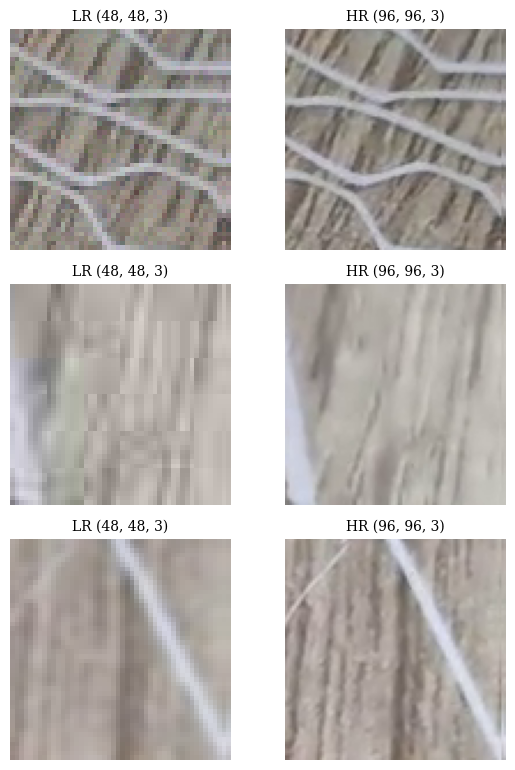

In [3]:
# What the model is actually fed: the LR patch and the HR patch it must
# reconstruct, whose side is EDSR_SCALE_FACTOR times larger.
_ = plot_patch_pairs(X_train, Y_train, count=3, seed=0)

In [4]:
model = EDSR()

model.setup_model(
    scale_factor=EDSR_SCALE_FACTOR, 
    num_res_blocks=16, 
    num_filters=64, 
    learning_rate=5e-5
)

Model: "EDSR"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 conv2d (Conv2D)                (None, None, None,   1792        ['input[0][0]']                  
                                64)                                                               
                                                                                                  
 conv2d_1 (Conv2D)              (None, None, None,   36928       ['conv2d[0][0]']                 
                                64)                                                            

In [5]:
# Train EDSR and capture callbacks for metrics
history, time_cb, mem_cb = model.fit(
    X_train, Y_train, X_val, Y_val, 
    batch_size=16, 
    epochs=300
)

Training on GPU: /physical_device:GPU:0
Epoch 1/300
897/897 [==============================] - 69s 71ms/step - loss: 0.1126 - psnr: 19.8954 - ssim: 0.4030 - val_loss: 0.0539 - val_psnr: 23.5105 - val_ssim: 0.5387 - lr: 5.0000e-05 - epoch_time_sec: 68.6517 - gpu_mean_current_mb: 1907.8779 - gpu_peak_mb: 2365.8918
Epoch 2/300
897/897 [==============================] - 62s 70ms/step - loss: 0.0496 - psnr: 24.3632 - ssim: 0.5701 - val_loss: 0.0495 - val_psnr: 24.4012 - val_ssim: 0.5307 - lr: 5.0000e-05 - epoch_time_sec: 62.4913 - gpu_mean_current_mb: 2118.5972 - gpu_peak_mb: 2521.2109
Epoch 3/300
897/897 [==============================] - 63s 70ms/step - loss: 0.0440 - psnr: 25.4957 - ssim: 0.6155 - val_loss: 0.0424 - val_psnr: 25.8215 - val_ssim: 0.6095 - lr: 5.0000e-05 - epoch_time_sec: 62.5596 - gpu_mean_current_mb: 2118.5972 - gpu_peak_mb: 2522.8838
Epoch 4/300
897/897 [==============================] - 63s 70ms/step - loss: 0.0398 - psnr: 26.3900 - ssim: 0.6567 - val_loss: 0.0393 - va

In [6]:
del X_train, Y_train, X_val, Y_val  # Free memory
gc.collect()  # Force garbage collection to free memory

1447

In [7]:
# Evaluates the run, saves the checkpoint and the metrics under one
# timestamp, so the reporting notebooks resolve a single run.
timestamp, run_dir, metrics = model.evaluate_and_save(
    X_test, Y_test, history, time_cb, mem_cb,
)


 EDSR run 20260914_204828
  evaluating on the test partition
125/125 [==============================] - 6s 43ms/step - loss: 0.0307 - psnr: 28.8150 - ssim: 0.7632
Loss: 0.0307, PSNR: 28.82 dB, SSIM: 0.7632
Model saved to c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\EDSR\EDSR_20260914_204828\EDSR_x2_20260914_204828.h5
  metrics    -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\EDSR\EDSR_20260914_204828\EDSR_20260914_204828_metrics.pkl
  summary    -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\EDSR\EDSR_20260914_204828\EDSR_20260914_204828_summary.txt
  epochs     -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\EDSR\EDSR_20260914_204828\EDSR_20260914_204828_epochs_data.txt
